# Lab 5: Clustering Techniques on Wine Dataset <br>
**Name:** Prashanna Acharya <br>
**Course Title:** MSCS 634  <br>
**Lab Assignment:** Lab 5 – Hierarchical & DBSCAN Clustering <br>


### Importing Libraries and Setting Up

In [9]:
# Importing necessary libraries for data handling, clustering, and visualization

import pandas as pd        # importing pandas for data manipulation
import numpy as np         # importing numpy for numerical operations
import matplotlib.pyplot as plt  # importing matplotlib for plotting
import seaborn as sns      # importing seaborn for enhanced visualizations

from sklearn.datasets import load_wine        # loading wine dataset
from sklearn.preprocessing import StandardScaler  # standardizing the features
from sklearn.cluster import AgglomerativeClustering, DBSCAN  # importing clustering algorithms
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score  # importing evaluation metrics
from scipy.cluster.hierarchy import dendrogram, linkage  # importing for dendrogram


### Step 1: Data Preparation and Exploration

In [10]:
# Loading the Wine dataset

wine_data = load_wine()               # loading wine dataset from sklearn
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)  # converting data into pandas DataFrame

# Exploring the dataset

df.head()       # displaying first 5 rows to get an initial understanding
df.info()       # checking data types and null values
df.describe()   # generating descriptive statistics to see distributions

# Standardizing the dataset

scaler = StandardScaler()        # initializing standard scaler
df_scaled = scaler.fit_transform(df)   # standardizing features to have mean=0 and std=1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

### Step 2: Hierarchical Clustering

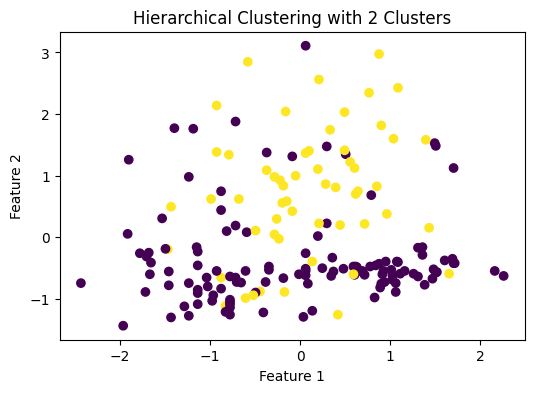

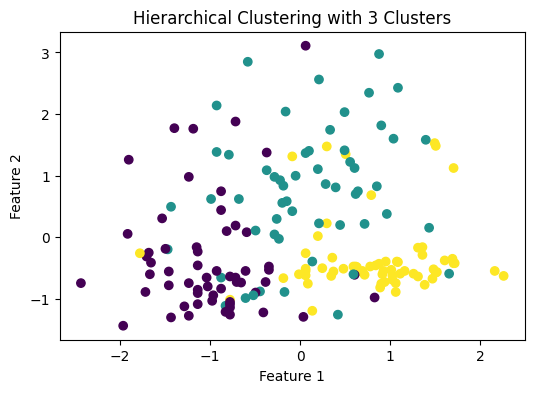

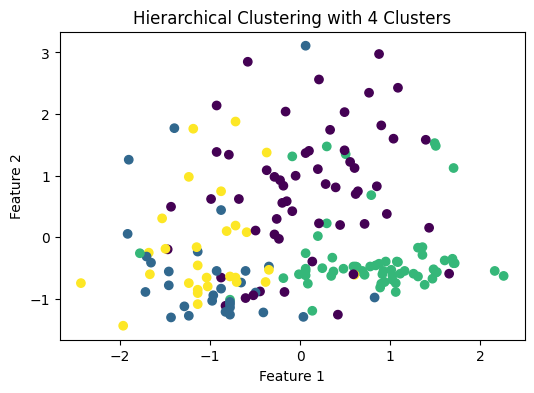

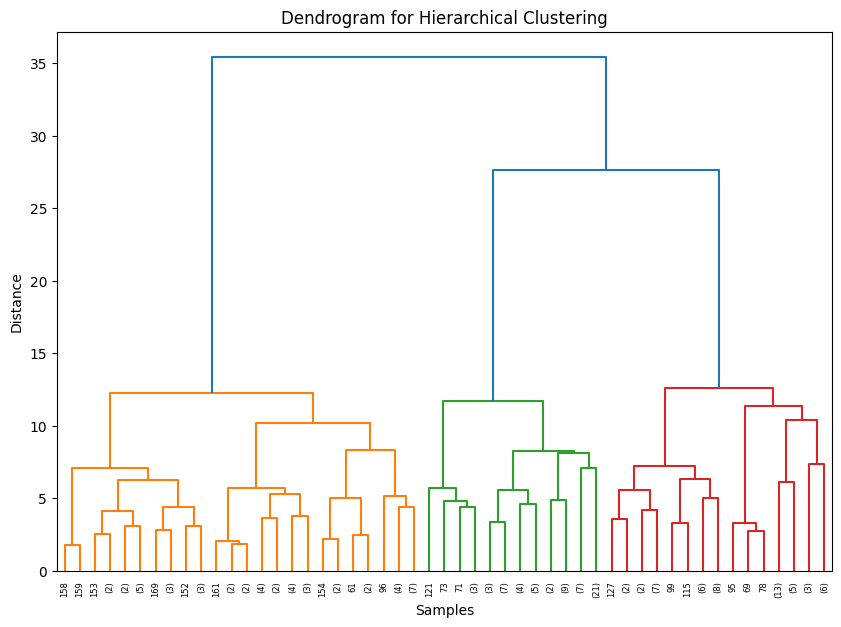

In [11]:
# Performing Agglomerative Hierarchical Clustering

# Trying different numbers of clusters and visualizing results

for n_clusters in [2, 3, 4]:  # testing multiple cluster numbers
    hc = AgglomerativeClustering(n_clusters=n_clusters)  # initializing hierarchical clustering
    cluster_labels = hc.fit_predict(df_scaled)           # fitting and predicting clusters

    # plotting scatter of first two principal features for visualization
    plt.figure(figsize=(6,4))
    plt.scatter(df_scaled[:, 0], df_scaled[:, 1], c=cluster_labels, cmap='viridis')  # plotting clusters
    plt.title(f'Hierarchical Clustering with {n_clusters} Clusters')  # setting plot title
    plt.xlabel('Feature 1')  # labeling x-axis
    plt.ylabel('Feature 2')  # labeling y-axis
    plt.show()  # displaying the plot

# Generating a dendrogram

linked = linkage(df_scaled, method='ward')   # performing hierarchical linkage using Ward method
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5)  # plotting truncated dendrogram for readability
plt.title('Dendrogram for Hierarchical Clustering')  # setting dendrogram title
plt.xlabel('Samples')   # labeling x-axis
plt.ylabel('Distance')  # labeling y-axis
plt.show()  # displaying dendrogram


### Step 3: DBSCAN Clustering

Number of clusters found (excluding noise): 0


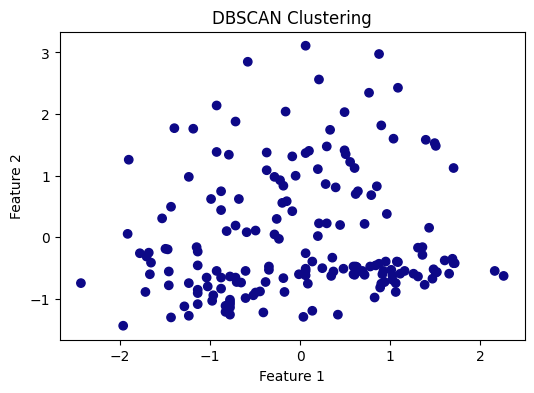

DBSCAN produced less than 2 clusters. Metrics cannot be computed.


In [12]:
# Step 3: DBSCAN Clustering Metrics 

# Counting clusters excluding noise
labels_unique = set(db_labels)
n_clusters = len(labels_unique) - (1 if -1 in labels_unique else 0)
print(f"Number of clusters found (excluding noise): {n_clusters}")

# Plotting DBSCAN clusters
plt.figure(figsize=(6,4))
plt.scatter(df_scaled[:, 0], df_scaled[:, 1], c=db_labels, cmap='plasma')
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Computing metrics safely
if n_clusters >= 2:
    # excluding noise for silhouette score
    mask = db_labels != -1
    sil_score = silhouette_score(df_scaled[mask], db_labels[mask])
    
    # computing homogeneity and completeness (including noise is fine)
    homo_score = homogeneity_score(wine_data.target, db_labels)
    comp_score = completeness_score(wine_data.target, db_labels)

    print(f"Silhouette Score: {sil_score:.3f}")
    print(f"Homogeneity Score: {homo_score:.3f}")
    print(f"Completeness Score: {comp_score:.3f}")
else:
    print("DBSCAN produced less than 2 clusters. Metrics cannot be computed.")


### Step 4: Analysis and Insights

- Observing how hierarchical clustering is forming nested clusters and visualizing via dendrograms.
- Analyzing how DBSCAN identifies dense regions and labels sparse points as noise.
- Noticing how parameter choices like n_clusters in hierarchical clustering and eps in DBSCAN affect outcomes.
- Comparing strengths: Hierarchical gives structured hierarchy, DBSCAN detects arbitrary-shaped clusters and noise.
- Discussing weaknesses: Hierarchical is sensitive to scaling and outliers, DBSCAN depends on density parameters.
